# 01 - Data Exploration

Goal: understand the dataset before changing anything.
Source: UK DfT STATS19, Road Safety Data (last 5 years).

In [22]:
import sys
sys.path.append("..")          

import pandas as pd
import matplotlib.pyplot as plt

from src import config

pd.set_option("display.max_columns", None)

In [23]:
df = pd.read_csv(config.COLLISIONS_FILE, low_memory=False)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 513801
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,1,15/02/2025,7,19:15,-1,E06000002,E06000002,E06000002,6,0,6,30,-1,16,4,6,0,-1,-1,0,4,1,1,-1,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,1,22/10/2024,3,14:48,-1,E06000004,E06000004,E06000004,3,139,6,30,-1,0,-1,-1,-1,-1,-1,0,1,1,1,-1,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,1,19/12/2025,6,06:40,-1,E06000005,E06000005,E06000005,6,0,6,30,-1,13,4,3,68,-1,-1,0,4,2,2,-1,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,1,22/04/2025,3,20:03,-1,E06000006,E06000006,E06000006,4,5155,6,30,-1,0,-1,0,-1,-1,-1,0,1,1,1,-1,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,1,28/04/2025,2,17:40,-1,E06000006,E06000006,E06000006,4,5155,6,30,-1,16,4,4,5155,-1,-1,13,1,1,1,-1,-1,0,1,2,2,E01012431,3,1,0.0,1.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   513801 non-null  object 
 1   collision_year                                    513801 non-null  int64  
 2   collision_ref_no                                  513801 non-null  object 
 3   location_easting_osgr                             513748 non-null  float64
 4   location_northing_osgr                            513748 non-null  float64
 5   longitude                                         513748 non-null  float64
 6   latitude                                          513748 non-null  float64
 7   police_force                                      513801 non-null  int64  
 8   collision_severity                                513801 non-null  int64  
 9   numb

In [25]:
for name in df.columns:
    print(name)

collision_index
collision_year
collision_ref_no
location_easting_osgr
location_northing_osgr
longitude
latitude
police_force
collision_severity
number_of_vehicles
number_of_casualties
date
day_of_week
time
local_authority_district
local_authority_ons_district
local_authority_highway
local_authority_highway_current
first_road_class
first_road_number
road_type
speed_limit
junction_detail_historic
junction_detail
junction_control
second_road_class
second_road_number
pedestrian_crossing_human_control_historic
pedestrian_crossing_physical_facilities_historic
pedestrian_crossing
light_conditions
weather_conditions
road_surface_conditions
special_conditions_at_site
carriageway_hazards_historic
carriageway_hazards
urban_or_rural_area
did_police_officer_attend_scene_of_accident
trunk_road_flag
lsoa_of_accident_location
enhanced_severity_collision
collision_injury_based
collision_adjusted_severity_serious
collision_adjusted_severity_slight


In [26]:
missing = df.isna().sum()
missing[missing > 0]

location_easting_osgr     53
location_northing_osgr    53
longitude                 53
latitude                  53
dtype: int64

In [27]:
# STATS19 stores missing values as -1, not as blank.
# Pandas reads -1 as a normal number, so isna() cannot find it.
minus_one = (df == -1).sum().sort_values(ascending=False)
minus_one[minus_one > 0]

local_authority_district                            513607
junction_control                                    217897
enhanced_severity_collision                         204752
second_road_number                                  178098
special_conditions_at_site                          151370
carriageway_hazards_historic                        151367
pedestrian_crossing_human_control_historic          150889
pedestrian_crossing_physical_facilities_historic    150860
junction_detail_historic                            147476
trunk_road_flag                                      36318
junction_detail                                      19982
second_road_class                                    11566
pedestrian_crossing                                  11238
carriageway_hazards                                   9891
road_surface_conditions                               3527
light_conditions                                        34
weather_conditions                                      

In [28]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [29]:
counts = df[config.TARGET].value_counts().sort_index()
percent = (counts / len(df) * 100).round(2)

pd.DataFrame({
    "count": counts,
    "percent": percent,
    "label": [config.SEVERITY_LABELS[i] for i in counts.index],
})

,count,percent,label
collision_severity,,,
1,7553,1.47,Fatal
2,116813,22.74,Serious
3,389435,75.79,Slight


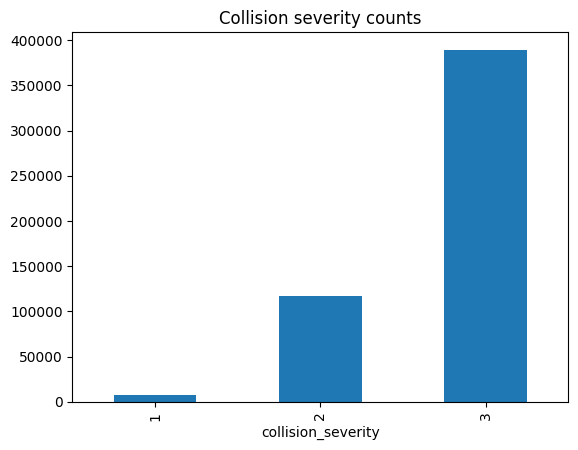

In [30]:
counts.plot(kind="bar", title="Collision severity counts")
plt.show()